# Uplift Modeling: Launch to Whom?

Notebook 06 ended with a deliberate non-launch: the personalized-playlist module lifts 14-day retention **+2.6pp on average** but breaches the skip-rate guardrail, and the segment drill-down showed the average hides wild heterogeneity — low-activity listeners gain +4.4pp while high-skippers gain nothing. An average treatment effect answers *whether* to launch. This notebook answers *to whom*: estimate each user's **individual treatment effect** (uplift) on D14 retention with hand-rolled meta-learners, and turn the estimates into a targeting policy with an explicit expected impact.

Because the experiment is simulated, every user's true uplift is stored in the dataset (`true_uplift_pp`, hidden from the models). That enables a validation production teams never get — predicted uplift scored directly against ground truth — and this notebook uses it, while flagging exactly where that luxury does and does not transfer.

**Dependencies:** `data/experiment_results.csv.gz` from `python -m src.experiment_simulation` (notebook 06); meta-learners and evaluation utilities in `src/uplift_modeling.py` (plain scikit-learn, unit-tested in `tests/` — no heavy causal-inference dependency).

## 1. Why the Average Is Not Enough

Notebook 06's scorecard, by design segment:

| Segment | Share | Measured lift | Injected truth |
|---|---|---|---|
| low_activity | 32% | +4.4pp | +5.0pp |
| mid_activity | 35% | +1.8pp | +2.2pp |
| high_activity | 18% | +2.2pp | +0.5pp |
| high_skipper | 15% | −0.3pp | −1.5pp |

A full launch treats all four rows identically and pays the skip-rate cost (+3pp for every treated retained user) everywhere — including where the retention gain is zero or negative. Uplift modeling generalizes the drill-down: instead of four pre-registered segments, estimate a **conditional average treatment effect for every user** from pre-experiment covariates, then target where the effect is worth the guardrail cost.

## 2. Three Meta-Learners, Hand-Rolled

All three reduce causal estimation to standard supervised learning (which is why no causal library is needed — each is a few lines of scikit-learn, implemented and unit-tested in `src/uplift_modeling.py`):

- **S-learner** — one model with treatment as an extra feature; uplift = predicted outcome with the flag on minus off. Lowest variance, but if the base learner underuses the treatment feature the heterogeneity shrinks toward zero.
- **T-learner** — separate outcome models per arm; uplift = the difference of their predictions. No shared-model bias, but it differences two independently noisy models.
- **X-learner** — T-learner first, then each user's *missing* potential outcome is imputed with the opposite arm's model, individual effects are regressed directly, and the two effect models are blended by the treatment propensity (0.5 here). Usually the best bias/variance tradeoff when effects are smooth.

The base learner is injectable; the default is the gradient-boosting configuration that won notebook 07's tuned search. Every learner refuses to fit if the treatment assignment fails the SRM check from `src/ab_testing.py` — meta-learners are causal only under randomization.

## 3. Data, Features, and Split

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src.config import RANDOM_SEED
from src.uplift_modeling import (
    SLearner,
    TLearner,
    XLearner,
    qini_coefficient,
    qini_curve,
    uplift_by_decile,
    validate_against_true_uplift,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

LEARNER_COLORS = {"x_learner": "#1f77b4", "t_learner": "#ff7f0e",
                  "s_learner": "#9467bd"}
NEUTRAL_COLOR = "#7f7f7f"

experiment = pd.read_csv(REPO_ROOT / "data" / "experiment_results.csv.gz")

# Pre-experiment covariates only. Excluded on purpose:
#   churn_label_14d    the control-arm potential outcome (post-assignment
#                      information a production model would not have)
#   effect_segment,    simulator internals — ground truth reserved for
#   true_uplift_pp     validation, never for fitting
FEATURE_COLUMNS = ["tenure_days", "active_days_30d", "listen_minutes_30d",
                   "skip_rate_30d", "playlist_adds_30d", "ad_revenue_30d",
                   "cancel_count_30d", "current_subscription_type"]
X_design = pd.get_dummies(experiment[FEATURE_COLUMNS],
                          columns=["current_subscription_type"],
                          drop_first=True, dtype=float)
treatment = (experiment["group"] == "treatment").astype(int).to_numpy()
outcome = experiment["retained_14d_post"].to_numpy()
true_uplift = (experiment["true_uplift_pp"] / 100).to_numpy()

train_idx, test_idx = train_test_split(
    np.arange(len(experiment)), test_size=0.3,
    random_state=RANDOM_SEED, stratify=treatment,
)
X_train, X_test = X_design.iloc[train_idx].to_numpy(), X_design.iloc[test_idx].to_numpy()
print(f"Users: {len(experiment):,} | features: {X_design.shape[1]} | "
      f"train {len(train_idx):,} / test {len(test_idx):,}")
print(f"ATE recap (measured in notebook 06): +2.58pp; injected truth: +2.2pp")

Users: 33,473 | features: 8 | train 23,431 / test 10,042
ATE recap (measured in notebook 06): +2.58pp; injected truth: +2.2pp


In [2]:
learners = {
    "s_learner": SLearner(),
    "t_learner": TLearner(),
    "x_learner": XLearner(),
}
predicted = {}
for name, learner in learners.items():
    learner.fit(X_train, treatment[train_idx], outcome[train_idx])  # SRM-guarded
    predicted[name] = learner.predict_uplift(X_test)
print("Fitted:", ", ".join(learners))

Fitted: s_learner, t_learner, x_learner


## 4. Evaluation on Held-Out Users

Three views, weakest to strongest evidence: Qini curves (observed-outcome ranking quality), uplift by predicted quintile (observed treatment-vs-control gaps), and — the simulated-data payoff — direct validation against the true per-user uplift.

In [3]:
y_test, t_test = outcome[test_idx], treatment[test_idx]
true_test = true_uplift[test_idx]

rng = np.random.default_rng(RANDOM_SEED)
baselines = {"oracle (true uplift)": true_test,
             "random targeting": rng.random(len(test_idx))}

evaluation = pd.DataFrame([
    {"model": name,
     "qini_coefficient": qini_coefficient(y_test, t_test, scores),
     **(validate_against_true_uplift(predicted[name], true_test)
        if name in predicted else {})}
    for name, scores in {**predicted, **baselines}.items()
])
evaluation.round(5)

,model,qini_coefficient,mse,rank_correlation,pearson_correlation
0,s_learner,0.00036,0.00079,0.40866,0.19506
1,t_learner,0.00092,0.00366,0.25586,0.21681
2,x_learner,0.00124,0.00056,0.44489,0.39995
3,oracle (true uplift),0.00249,NaN,NaN,NaN
4,random targeting,0.00118,NaN,NaN,NaN


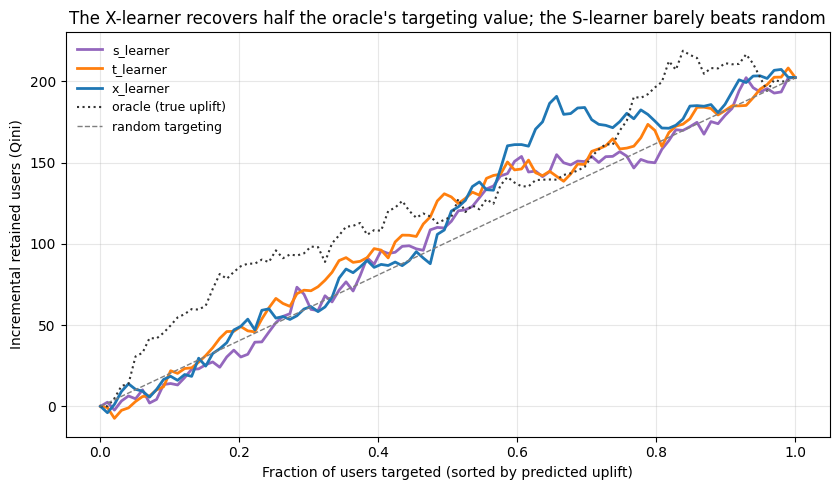

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for name, scores in predicted.items():
    curve = qini_curve(y_test, t_test, scores)
    ax.plot(curve["fraction_targeted"].to_numpy(),
            curve["incremental_responders"].to_numpy(),
            color=LEARNER_COLORS[name], linewidth=2, label=name)
oracle_curve = qini_curve(y_test, t_test, true_test)
ax.plot(oracle_curve["fraction_targeted"].to_numpy(),
        oracle_curve["incremental_responders"].to_numpy(),
        color="#333333", linewidth=1.5, linestyle=":", label="oracle (true uplift)")
endpoint = oracle_curve["incremental_responders"].iloc[-1]
ax.plot([0, 1], [0, endpoint], color=NEUTRAL_COLOR, linestyle="--",
        linewidth=1, label="random targeting")
ax.set_xlabel("Fraction of users targeted (sorted by predicted uplift)")
ax.set_ylabel("Incremental retained users (Qini)")
ax.set_title("The X-learner recovers half the oracle's targeting value; "
             "the S-learner barely beats random")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The X-learner wins on every criterion — Qini 0.0012 (oracle: 0.0025), rank correlation with truth 0.45, and the lowest MSE. The T-learner ranks decently but its uplift magnitudes are the noisiest (MSE 6x the X-learner's — the cost of differencing two independent models). The S-learner shows the classic failure: reasonable rank correlation but heterogeneity shrunk toward the ATE, so its targeting value is barely above random.

,decile,n_users,mean_predicted_uplift,treated_rate,control_rate,observed_uplift
0,1,2009,0.0447,0.3290,0.2826,0.0464
1,2,2008,0.0296,0.3604,0.3201,0.0403
2,3,2008,0.0162,0.5436,0.4679,0.0758
3,4,2008,0.0043,0.6102,0.6069,0.0034
4,5,2009,-0.0073,0.5680,0.5457,0.0223


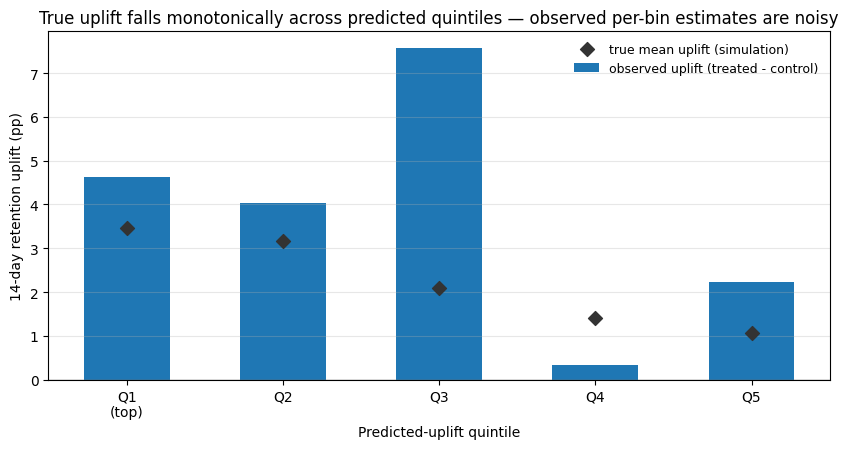

In [5]:
best_name = "x_learner"
best_scores = predicted[best_name]

quintiles = uplift_by_decile(y_test, t_test, best_scores, n_bins=5)
display(quintiles.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
xpos = np.arange(len(quintiles))
ax.bar(xpos, quintiles["observed_uplift"].to_numpy() * 100,
       color=LEARNER_COLORS[best_name], width=0.55,
       label="observed uplift (treated - control)")
sorted_true = true_test[np.argsort(-best_scores)]
true_by_bin = [sorted_true[int(i * len(sorted_true) / 5):
                           int((i + 1) * len(sorted_true) / 5)].mean() * 100
               for i in range(5)]
ax.scatter(xpos, true_by_bin, color="#333333", marker="D", s=50, zorder=3,
           label="true mean uplift (simulation)")
ax.axhline(0, color=NEUTRAL_COLOR, linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels([f"Q{i+1}\n(top)" if i == 0 else f"Q{i+1}" for i in range(5)])
ax.set_xlabel("Predicted-uplift quintile")
ax.set_ylabel("14-day retention uplift (pp)")
ax.set_title("True uplift falls monotonically across predicted quintiles — "
             "observed per-bin estimates are noisy")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The diamonds (truth) fall cleanly from Q1 to Q5 — the ranking works. The bars (observed gaps) wobble because each quintile holds ~2,000 users split across two arms: the standard error of an observed per-bin uplift is ~±3pp, larger than most of the true effects being estimated. **This is the fundamental noise floor of uplift evaluation**, and exactly why the ground-truth check below matters.

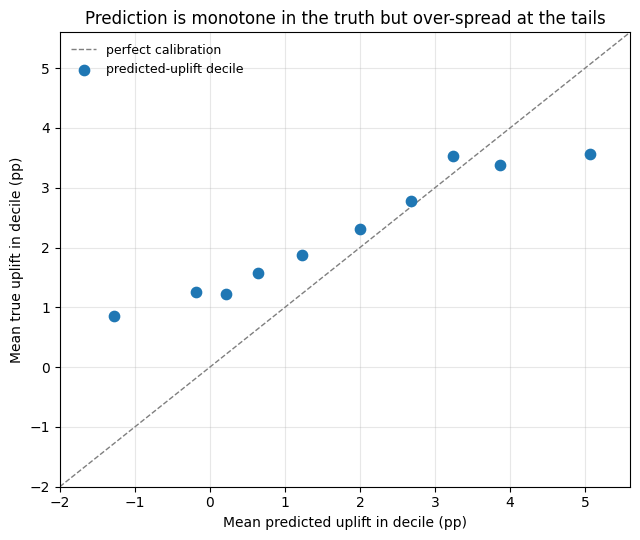

Mean predicted vs true uplift by (hidden) design segment:
               predicted_pp  true_pp
segment                             
low_activity           3.20      5.0
mid_activity           1.16      2.2
high_activity          0.45      0.5
high_skipper           1.61     -1.5


In [6]:
calibration = pd.DataFrame({
    "predicted": best_scores, "true": true_test,
})
calibration["bin"] = pd.qcut(
    calibration["predicted"].rank(method="first", ascending=False), 10, labels=False
)
binned = calibration.groupby("bin")[["predicted", "true"]].mean() * 100

fig, ax = plt.subplots(figsize=(6.5, 5.5))
lims = [-2, 5.6]
ax.plot(lims, lims, color=NEUTRAL_COLOR, linestyle="--", linewidth=1,
        label="perfect calibration")
ax.scatter(binned["predicted"].to_numpy(), binned["true"].to_numpy(),
           color=LEARNER_COLORS[best_name], s=55, zorder=3,
           label="predicted-uplift decile")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Mean predicted uplift in decile (pp)")
ax.set_ylabel("Mean true uplift in decile (pp)")
ax.set_title("Prediction is monotone in the truth but over-spread at the tails")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

segment_check = (
    pd.DataFrame({"segment": experiment.iloc[test_idx]["effect_segment"].to_numpy(),
                  "predicted_pp": best_scores * 100,
                  "true_pp": true_test * 100})
    .groupby("segment").mean().round(2)
    .sort_values("true_pp", ascending=False)
)
print("Mean predicted vs true uplift by (hidden) design segment:")
print(segment_check.to_string())

Two honest takeaways from the truth check — **only possible because this is simulation; a production team sees neither panel**:

1. **Calibration is monotone but over-spread**: the top decile predicts +5.1pp where the truth is +3.6pp, and the bottom decile predicts −1.3pp where the truth is +0.9pp. Rank with the scores; do not read them as literal effect sizes.
2. **The model misses the harmed minority.** The hidden high-skipper segment (true −1.5pp) gets a *predicted* +1.6pp: a −1.5pp effect on a 15% segment is simply below the detection floor at 33K users, and the model's smoothing pulls the segment toward its high-uplift low-activity neighbors. **Consequence: the targeting policy cannot rely on the model to exclude harmed users — the known guardrail rule must stay explicit.**

## 5. Targeting Policy: Whom to Treat, and What It Buys

Policy construction combines the model with the one thing notebook 06 *proved*: skip-heavy users are harmed. The candidate policies below are compared on truth-based accounting (the simulation luxury), scaled to the full 33,473-user cohort.

In [7]:
test_frame = experiment.iloc[test_idx].copy()
test_frame["predicted_uplift"] = best_scores
test_frame["true_uplift"] = true_test
scale = len(experiment) / len(test_frame)
full_launch_value = test_frame["true_uplift"].sum()

PRACTICAL_BAR = 0.02  # the +2pp practical-value bar from notebook 06's design
policies = {
    "no launch": pd.Series(False, index=test_frame.index),
    "full launch": pd.Series(True, index=test_frame.index),
    "model only (pred >= +2pp)": test_frame["predicted_uplift"] >= PRACTICAL_BAR,
    "guardrail only (skip_rate <= 0.35)": test_frame["skip_rate_30d"] <= 0.35,
    "combined (model + guardrail)": (test_frame["predicted_uplift"] >= PRACTICAL_BAR)
                                    & (test_frame["skip_rate_30d"] <= 0.35),
}
policy_rows = []
for name, mask in policies.items():
    captured = test_frame.loc[mask, "true_uplift"].sum()
    policy_rows.append({
        "policy": name,
        "share_targeted": mask.mean(),
        "incremental_retained_cohort": captured * scale,
        "share_of_full_launch_value": captured / full_launch_value if full_launch_value else 0,
        "avg_true_uplift_of_targeted_pp": (
            test_frame.loc[mask, "true_uplift"].mean() * 100 if mask.any() else 0.0
        ),
    })
policy_table = pd.DataFrame(policy_rows)
policy_table.round(3)

,policy,share_targeted,incremental_retained_cohort,share_of_full_launch_value,avg_true_uplift_of_targeted_pp
0,no launch,0.000,0.000,0.000,0.000
1,full launch,1.000,748.069,1.000,2.235
2,model only (pred >= +2pp),0.451,484.129,0.647,3.205
3,guardrail only (skip_rate <= 0.35),0.852,822.518,1.100,2.885
4,combined (model + guardrail),0.379,520.578,0.696,4.107


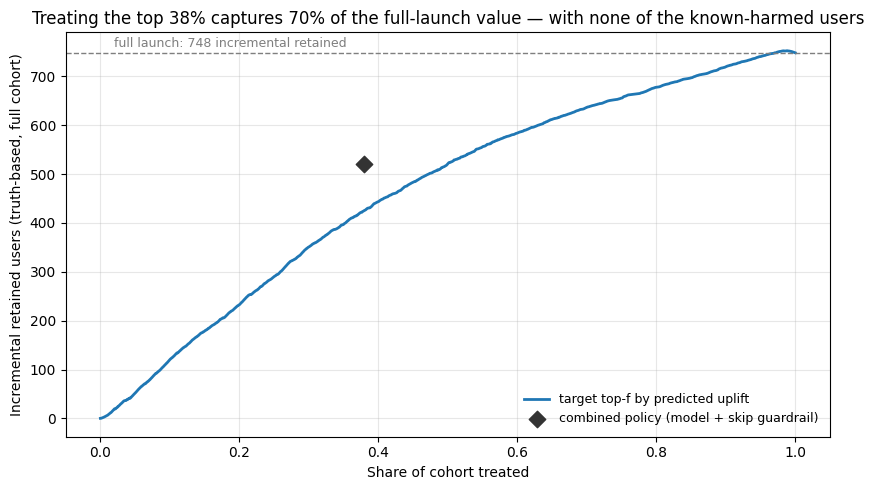

Recommended policy: predicted uplift >= +2pp AND skip_rate_30d <= 0.35
  targets 37.9% of the cohort
  expected incremental retained: 521 users (vs 748 full launch, 0 no launch)
  avg true uplift among targeted: 4.1pp (vs 2.2pp cohort-wide)


In [8]:
order = np.argsort(-test_frame["predicted_uplift"].to_numpy())
cum_true = np.cumsum(test_frame["true_uplift"].to_numpy()[order]) * scale
fractions = np.arange(1, len(order) + 1) / len(order)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(fractions, cum_true, color=LEARNER_COLORS["x_learner"], linewidth=2,
        label="target top-f by predicted uplift")
ax.axhline(full_launch_value * scale, color=NEUTRAL_COLOR, linestyle="--",
           linewidth=1)
ax.text(0.02, full_launch_value * scale + 12,
        f"full launch: {full_launch_value * scale:.0f} incremental retained",
        fontsize=9, color=NEUTRAL_COLOR)
combined_mask = policies["combined (model + guardrail)"]
ax.scatter([combined_mask.mean()],
           [test_frame.loc[combined_mask, "true_uplift"].sum() * scale],
           color="#333333", marker="D", s=70, zorder=3,
           label="combined policy (model + skip guardrail)")
ax.set_xlabel("Share of cohort treated")
ax.set_ylabel("Incremental retained users (truth-based, full cohort)")
ax.set_title("Treating the top 38% captures 70% of the full-launch value — "
             "with none of the known-harmed users")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

combined = policy_table.set_index("policy").loc["combined (model + guardrail)"]
print(f"Recommended policy: predicted uplift >= +2pp AND skip_rate_30d <= 0.35")
print(f"  targets {combined['share_targeted']:.1%} of the cohort")
print(f"  expected incremental retained: {combined['incremental_retained_cohort']:.0f} "
      f"users (vs {full_launch_value * scale:.0f} full launch, 0 no launch)")
print(f"  avg true uplift among targeted: "
      f"{combined['avg_true_uplift_of_targeted_pp']:.1f}pp "
      f"(vs 2.2pp cohort-wide)")

Reading the policy table:

- **Full launch** earns 748 incremental retained users but exposes everyone — including the 15% it actively harms — to the +3pp skip-rate degradation that blocked the launch in the first place.
- **Model-only targeting** (predicted uplift above the +2pp practical bar) treats 45% of users for 65% of the value — but the calibration check showed it *cannot see* the harmed segment, so ~half the high-skippers slip through.
- **Guardrail-only** captures the most retention value (it even beats full launch, because excluding negative-uplift users adds value) — but it still exposes 85% of the cohort, most of whom gain little, to the skip-rate cost. (Its "perfect" harm exclusion is partly an artifact: the simulator defines the harmed segment by this exact covariate; in production the rule would come from notebook 06's segment drill-down and be approximate.)
- **Combined (recommended): treat users with predicted uplift ≥ +2pp AND skip rate ≤ 0.35** — 38% of the cohort, ~521 incremental retained users (70% of full-launch value), zero users from the known-harmed segment, and an average true uplift of +4.1pp among the targeted vs +2.2pp cohort-wide: nearly double the value density per exposed user.

## 6. Key Findings

The 06 → 09 arc: the experiment said *the module works on average but not for everyone and it breaches a guardrail*; uplift modeling turns that into *these users, this expected impact, these controls*.

- **The X-learner is the right tool here**: Qini 0.0012 vs the oracle's 0.0025 and random's ~0, rank correlation 0.45 with true uplift, lowest MSE. The S-learner shrinks heterogeneity toward the average (barely beats random targeting); the T-learner's estimates are 6x noisier.
- **Ranking works, magnitudes don't**: true uplift falls monotonically across predicted quintiles, but tails are over-spread (top decile predicts +5.1pp vs +3.6pp truth). Use uplift scores to order users, never as literal effect sizes.
- **The model cannot detect the harmed minority** — the −1.5pp high-skipper segment is predicted at +1.6pp; effects that small on segments that thin are below the detection floor at this scale. Guardrail rules earned by experiment (notebook 06) stay explicit in the policy; a model score never replaces them.
- **Recommended rollout policy: predicted uplift ≥ +2pp and skip rate ≤ 0.35** — treats 37.9% of the cohort, expects **~521 incremental retained users vs 748 for full launch and 0 for no launch**, excludes every known-harmed user, and doubles the value density per exposed user (+4.1pp vs +2.2pp average true uplift).
- **Next step is a targeted experiment, not a targeted launch**: rerun the notebook-06 design on the policy population (the power analysis machinery is already built), primary metric D14 retention, skip-rate guardrail re-measured *within* the targeted group, and the uplift model's decile ranking validated against the new experiment's observed gaps before any full rollout.

**Caveats.** All truth-based numbers (521, 748, calibration, the harmed-segment miss) are observable only because the experiment is simulated with stored ground truth; a production version of this notebook would stop at Qini curves, observed decile gaps, and a holdout-validated policy estimate. Covariates are pre-experiment behavioral aggregates; a production system would refresh them and re-score. The policy threshold inherits notebook 06's +2pp practical-value bar — a business choice, not a statistical one.